# 51 — Contrastive learning and InfoNCE

Contrastive learning trains representations by comparing examples rather than predicting a manually assigned class. Two augmented views of the same image form a **positive pair**; views originating from different images act as **negative pairs**.

In this notebook we will:

- construct and visualize positive image pairs;
- L2-normalize embedding vectors;
- build a pairwise cosine-similarity matrix;
- study the effect of temperature;
- implement InfoNCE first with a loop and then in vectorized form;
- inspect how optimizing the loss changes positive and negative similarities.

The focus is the loss itself. Notebook 52 will use these ideas to train a small SimCLR model on CIFAR-10.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

## 1. Positive and negative pairs

Suppose an image $x_i$ is transformed twice by random augmentations $t$ and $t'$:

$$
x_i^{(a)} = t(x_i),
\qquad
x_i^{(b)} = t'(x_i).
$$

These two views form a positive pair because they originate from the same image. A view of another image $x_j$, where $j \ne i$, is treated as a negative for $x_i$.

This supplies training targets without class labels: the data pipeline already knows which views came from the same source image.

The simple augmentation function below uses random crops, flips, and brightness changes. These transformations preserve the likely object identity while altering pixels. Choosing augmentations is important: if a transformation removes information required by the downstream task, the model is explicitly encouraged to ignore that information.

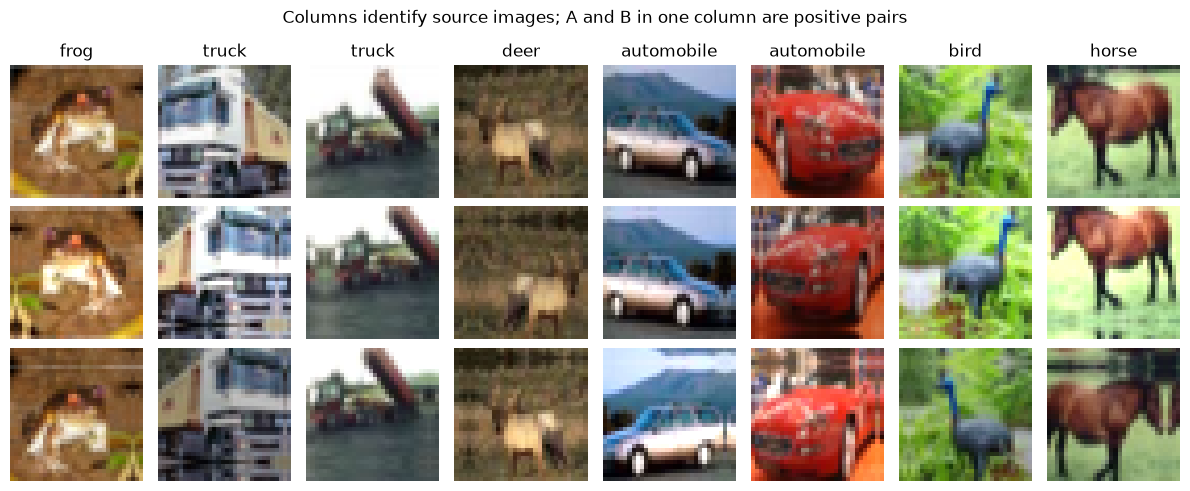

In [2]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
images = torch.from_numpy(dataset.data[:8]).permute(0, 3, 1, 2).float() / 255.0
labels = torch.tensor(dataset.targets[:8])  # Used only to label this visualization.


def augment_images(images, generator):
    # Apply independent crop, flip, and brightness changes to each image.
    padded = F.pad(images, (4, 4, 4, 4), mode="reflect")
    augmented = torch.empty_like(images)

    for index in range(len(images)):
        top = int(torch.randint(0, 9, (), generator=generator))
        left = int(torch.randint(0, 9, (), generator=generator))
        crop = padded[index, :, top:top + 32, left:left + 32]
        if float(torch.rand((), generator=generator)) < 0.5:
            crop = crop.flip(-1)
        brightness = float(
            torch.empty(()).uniform_(0.7, 1.3, generator=generator)
        )
        augmented[index] = (brightness * crop).clamp(0, 1)
    return augmented


view_a = augment_images(images, torch.Generator().manual_seed(1))
view_b = augment_images(images, torch.Generator().manual_seed(2))

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for column in range(8):
    for row, batch in enumerate((images, view_a, view_b)):
        axes[row, column].imshow(batch[column].permute(1, 2, 0))
        axes[row, column].axis("off")
    axes[0, column].set_title(CLASS_NAMES[int(labels[column])])
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("view A")
axes[2, 0].set_ylabel("view B")
plt.suptitle("Columns identify source images; A and B in one column are positive pairs")
plt.tight_layout()
plt.show()

### Exercise 1 — Identify pairs and augmentation assumptions

1. For `view_a[3]`, which tensor entry is its positive partner?
2. Which entries in `view_b` are treated as negatives for it?
3. Why might vertical flipping be an inappropriate augmentation for a task that must distinguish upright from upside-down objects?

**Your answers:**

1. view_b[3]
2. all but 3
3. Vertical flipping changes an upright object into an upside-down object. If the downstream task must distinguish these orientations, treating them as equivalent positive views teaches the model to ignore information it needs.

## 2. Normalize embedding vectors

An encoder and projection head produce an embedding $z_i \in \mathbb{R}^D$. Contrastive learning commonly L2-normalizes it:

$$
\hat{z}_i = \frac{z_i}{\lVert z_i \rVert_2}.
$$

The normalized vector has length 1. Its direction is preserved while its original magnitude is removed. The dot product of two normalized vectors is their cosine similarity:

$$
\hat{z}_i^T\hat{z}_j=\frac{z_i^Tz_j}{\lVert z_i \rVert_2\lVert z_j \rVert_2}.
$$

### Exercise 2 — Implement row-wise L2 normalization

`embeddings` has shape `(N, D)`. Compute one norm per row while retaining shape `(N, 1)` so division broadcasts over the feature dimension. Clamp the norm to avoid division by zero.

In [6]:
def l2_normalize(embeddings, epsilon=1e-12):
    # Normalize every row of an (N, D) embedding matrix.
    # calculate one L2 norm per row with keepdim=True.
    norms = torch.norm(embeddings, dim=1, keepdim=True)
    # divide by norms after clamping them to at least epsilon.
    normalized = torch.divide(embeddings, torch.clamp(norms, min=epsilon))
    return normalized


example_embeddings = torch.tensor([
    [3.0, 4.0],
    [6.0, 8.0],
    [1.0, 0.0],
    [0.0, 0.0],
])
normalized_embeddings = l2_normalize(example_embeddings)

assert normalized_embeddings.shape == example_embeddings.shape
torch.testing.assert_close(normalized_embeddings[0], torch.tensor([0.6, 0.8]))
torch.testing.assert_close(normalized_embeddings[1], torch.tensor([0.6, 0.8]))
torch.testing.assert_close(
    normalized_embeddings.norm(dim=1),
    torch.tensor([1.0, 1.0, 1.0, 0.0]),
)
torch.testing.assert_close(
    normalized_embeddings,
    F.normalize(example_embeddings, dim=1),
)

## 3. The pairwise similarity matrix

A minibatch contains $N$ source images and two views of each one, giving $2N$ embeddings. We store them in this order:

$$
Z = [z_0^{(a)},\ldots,z_{N-1}^{(a)},z_0^{(b)},\ldots,z_{N-1}^{(b)}].
$$

After normalization, one matrix multiplication gives every pairwise cosine similarity:

$$
S = \hat{Z}\hat{Z}^T,
\qquad
S \in \mathbb{R}^{2N \times 2N}.
$$

Row $i$ contains the similarity of anchor $i$ to every possible comparison. The diagonal $S_{ii}$ compares an embedding with itself and should not participate in the loss. With this ordering, the positive index is

$$
p(i) = (i + N) \bmod 2N.
$$

### Exercise 3 — Compute all pairwise similarities

Complete the function with row normalization and one matrix multiplication.

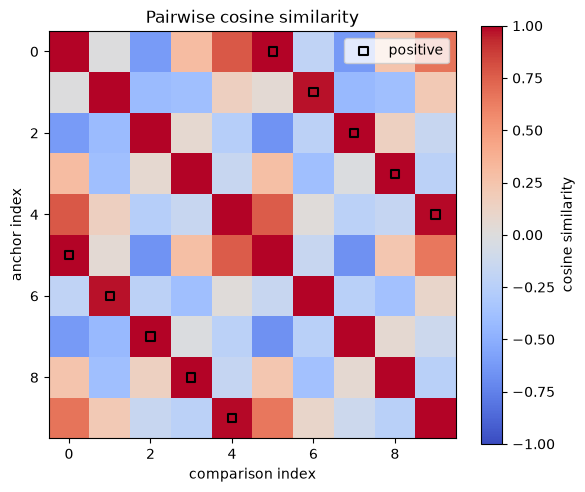

In [7]:
def pairwise_cosine_similarity(embeddings):
    # Return the cosine similarity between every pair of rows.
    # normalize rows, then multiply by the transpose.
    normalized_embeddings = l2_normalize(embeddings)
    return normalized_embeddings @ normalized_embeddings.T


number_of_sources = 5
generator = torch.Generator().manual_seed(8)
base = torch.randn(number_of_sources, 4, generator=generator)
toy_view_a = base + 0.10 * torch.randn(base.shape, generator=generator)
toy_view_b = base + 0.10 * torch.randn(base.shape, generator=generator)
toy_embeddings = torch.cat((toy_view_a, toy_view_b), dim=0)
similarities = pairwise_cosine_similarity(toy_embeddings)

assert similarities.shape == (10, 10)
torch.testing.assert_close(similarities, similarities.T)
torch.testing.assert_close(similarities.diag(), torch.ones(10))

positive_indices = (torch.arange(10) + number_of_sources) % 10
fig, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(similarities, vmin=-1, vmax=1, cmap="coolwarm")
axis.scatter(positive_indices, torch.arange(10), marker="s", facecolors="none",
             edgecolors="black", linewidths=1.5, label="positive")
axis.set(xlabel="comparison index", ylabel="anchor index", title="Pairwise cosine similarity")
axis.legend(loc="upper right")
fig.colorbar(image, ax=axis, label="cosine similarity")
plt.tight_layout()
plt.show()

## 4. Temperature controls the sharpness

InfoNCE divides similarity scores by a positive **temperature** $\tau$ before softmax:

$$
P(j\mid i)=\frac{\exp(S_{ij}/\tau)}
{\sum_{k \ne i}\exp(S_{ik}/\tau)}.
$$

A smaller temperature magnifies score differences and creates a sharper distribution. A larger temperature makes the probabilities more uniform. Temperature does not change which score is largest, but it changes how strongly the loss rewards and penalizes differences.

### Exercise 4 — Compare temperatures

Convert the four candidate similarities into probabilities for each temperature. Use `torch.softmax`; it performs the stable subtraction internally.

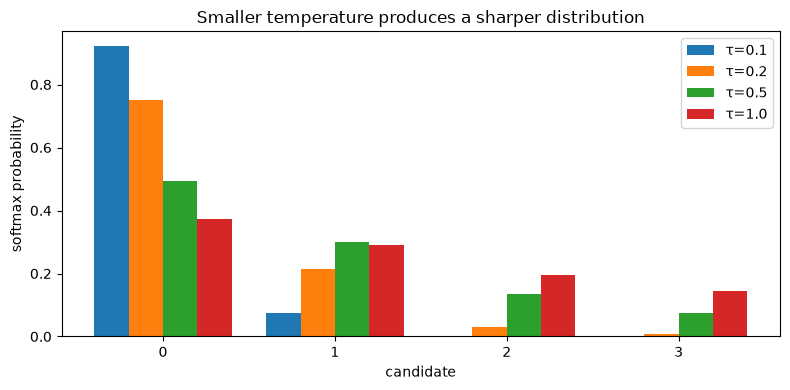

In [13]:
candidate_similarities = torch.tensor([0.85, 0.60, 0.20, -0.10])
temperatures = (0.1, 0.2, 0.5, 1.0)
temperature_probabilities = {}

for temperature in temperatures:
    # divide similarities by temperature and apply softmax.
    probabilities = torch.softmax(
        candidate_similarities / temperature,
        dim=0
    )
    temperature_probabilities[temperature] = probabilities

for probabilities in temperature_probabilities.values():
    torch.testing.assert_close(probabilities.sum(), torch.tensor(1.0))
    assert probabilities.argmax() == candidate_similarities.argmax()

fig, axis = plt.subplots(figsize=(8, 4))
x = np.arange(len(candidate_similarities))
width = 0.2
number_of_temperatures = len(temperatures)
for offset, (temperature, probabilities) in enumerate(temperature_probabilities.items()):
    centered_offset = offset - (number_of_temperatures - 1) / 2
    axis.bar(
        x + centered_offset * width,
        probabilities,
        width,
        label=f"τ={temperature}",
    )
axis.set(xticks=x, xlabel="candidate", ylabel="softmax probability",
         title="Smaller temperature produces a sharper distribution")
axis.legend()
plt.tight_layout()
plt.show()

## 5. InfoNCE for one anchor

For anchor $i$, InfoNCE treats its positive $p(i)$ as the correct answer among all other $2N-1$ embeddings:

$$
\ell_i=-\log
\frac{\exp(S_{i,p(i)}/\tau)}
{\sum_{k \ne i}\exp(S_{ik}/\tau)}.
$$

Important details:

- the positive is included in the denominator;
- only the anchor itself is excluded;
- every embedding serves once as an anchor, so both directions of each positive pair contribute;
- the batch mean is the final loss.

The same objective is often called **NT-Xent** in SimCLR: normalized temperature-scaled cross-entropy.

### Exercise 5 — Implement InfoNCE with an explicit loop

Use `torch.logsumexp` rather than calculating `log(exp(...).sum())`. `logsumexp` evaluates the same expression without unnecessary overflow or underflow.

In [ ]:
def info_nce_loss_loop(embeddings, temperature=0.2):
    # Calculate symmetric InfoNCE for embeddings ordered [view A; view B].
    if embeddings.ndim != 2 or embeddings.shape[0] % 2 != 0:
        raise ValueError("embeddings must have shape (2N, D)")
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    similarities = pairwise_cosine_similarity(embeddings)
    number_of_embeddings = embeddings.shape[0]
    number_of_sources = number_of_embeddings // 2
    losses = []

    for anchor in range(number_of_embeddings):
        positive = (anchor + number_of_sources) % number_of_embeddings
        valid = torch.arange(number_of_embeddings) != anchor
        scaled_scores = similarities[anchor] / temperature

        # negative positive score + logsumexp over all non-self scores.
        anchor_loss = (
            -scaled_scores[positive]
            + torch.logsumexp(scaled_scores[valid], dim=0)
        )
        losses.append(anchor_loss)

    return torch.stack(losses).mean()


loop_loss = info_nce_loss_loop(toy_embeddings, temperature=0.2)
assert loop_loss.ndim == 0
assert torch.isfinite(loop_loss)
print(f"loop InfoNCE loss: {loop_loss.item():.4f}")

loop InfoNCE loss: 0.2095


## 6. Vectorized InfoNCE

The complete loss can be expressed as one cross-entropy calculation:

1. compute the `(2N, 2N)` similarity matrix;
2. divide it by temperature;
3. replace diagonal self-similarities with negative infinity;
4. use `p(i)` as the target column for row $i$.

Although the matrix includes its diagonal columns, their logits are negative infinity and therefore contribute zero softmax probability.

### Exercise 6 — Remove the loop

Complete the vectorized implementation and confirm that it matches Exercise 5.

In [22]:
def info_nce_loss(embeddings, temperature=0.2):
    # Calculate vectorized symmetric InfoNCE for [view A; view B].
    if embeddings.ndim != 2 or embeddings.shape[0] % 2 != 0:
        raise ValueError("embeddings must have shape (2N, D)")
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    number_of_embeddings = embeddings.shape[0]
    number_of_sources = number_of_embeddings // 2

    # create temperature-scaled pairwise cosine logits.
    # (2N, D) → (2N, 2N), then apply temperature.
    logits = (
        pairwise_cosine_similarity(embeddings) / temperature
    )
    # exclude every self-comparison by filling the diagonal with -inf.
    logits.fill_diagonal_(float('-inf'))
    # calculate each anchor's positive column index.
    positive_indices = (torch.arange(number_of_embeddings) + number_of_sources) % number_of_embeddings
    # use cross_entropy with rows as examples and positive columns as targets.
    loss = nn.functional.cross_entropy(logits, positive_indices)
    return loss


vectorized_loss = info_nce_loss(toy_embeddings, temperature=0.2)
torch.testing.assert_close(vectorized_loss, loop_loss)
print(f"vectorized InfoNCE loss: {vectorized_loss.item():.4f}")

vectorized InfoNCE loss: 0.2095


## 7. What the loss changes

InfoNCE has two simultaneous effects:

- it increases similarity between the two views of each source image;
- it decreases their similarity relative to other examples in the batch.

The small experiment below optimizes the embedding values directly. A real model instead updates encoder and projection-head parameters, but gradients reach those parameters through the embeddings in exactly the same way.

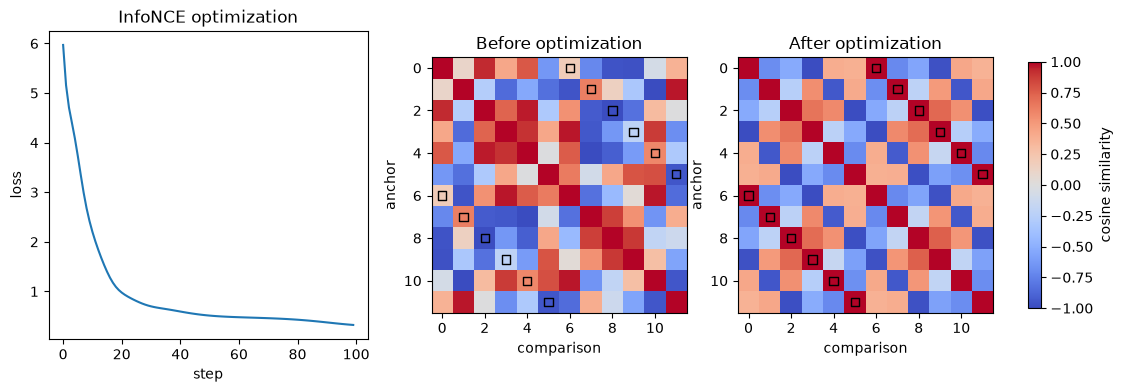

mean positive similarity: -0.128 -> 0.999


In [26]:
torch.manual_seed(12)
optimized_embeddings = nn.Parameter(torch.randn(12, 2))
optimizer = torch.optim.Adam([optimized_embeddings], lr=0.08)

with torch.no_grad():
    similarities_before = pairwise_cosine_similarity(optimized_embeddings).clone()

loss_history = []
for step in range(100):
    loss = info_nce_loss(optimized_embeddings, temperature=0.2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

with torch.no_grad():
    similarities_after = pairwise_cosine_similarity(optimized_embeddings)

positive_indices = (torch.arange(12) + 6) % 12
positive_before = similarities_before[torch.arange(12), positive_indices].mean()
positive_after = similarities_after[torch.arange(12), positive_indices].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(loss_history)
axes[0].set(title="InfoNCE optimization", xlabel="step", ylabel="loss")
for axis, matrix, title in zip(
    axes[1:],
    (similarities_before, similarities_after),
    ("Before optimization", "After optimization"),
):
    image = axis.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    axis.scatter(positive_indices, torch.arange(12), marker="s",
                 facecolors="none", edgecolors="black")
    axis.set(title=title, xlabel="comparison", ylabel="anchor")
fig.colorbar(image, ax=axes[1:], label="cosine similarity", shrink=0.8)
plt.show()

print(f"mean positive similarity: {positive_before:.3f} -> {positive_after:.3f}")

### Exercise 7 — Interpret the optimization

1. What happened to the average positive-pair similarity?
2. Why can all six positive pairs not point in six perfectly opposite directions in a two-dimensional embedding space?
3. In a real model, which parameters would the embedding gradients update?

**Your answers:**

1. it reached close to 1 value
2. Each positive pair can align internally, but six different pair directions cannot all be mutually opposite in two dimensions. Exact opposition is possible only between two antipodal directions, so the loss distributes the pairs around the unit circle instead.
3. The gradients would update both the projection head and the encoder parameters because the embeddings are produced by both components.

The chain is:

InfoNCE loss
    ↓
embedding gradients
    ↓
projection-head parameters
    ↓
encoder parameters

## 8. Collapse, false negatives, and batch size

### Why collapse is a possible shortcut

Imagine an objective that only minimizes the distance between two views of the same image:

$$
L_{\mathrm{align}} = \lVert z_i^{(a)}-z_i^{(b)} \rVert_2^2.
$$

A useful solution maps two cat views near one another while keeping them distinct from truck views. But the network can satisfy the stated objective even more easily by mapping **every** image to one constant vector. Every positive distance then equals zero, although the representation contains no information about the input. This failure is called **representational collapse**. It is possible because positive-only alignment says "make matching views similar" but does not say "keep different images distinguishable."

For example, the following positive pairs give zero alignment loss but are useless:

```text
cat view A   -> [0, 0]    cat view B   -> [0, 0]
truck view A -> [0, 0]    truck view B -> [0, 0]
```

### How InfoNCE discourages collapse

InfoNCE also asks the model to identify the positive among other examples. Suppose $N=2$, producing four embeddings `A1, B1, A2, B2`. For anchor `A1`, `A2` is positive, `B1` and `B2` are negatives, and `A1` itself is excluded. If all embeddings collapse, all three allowed similarities are equal. The positive therefore receives probability $1/3$, just like uniform guessing.

More generally, each anchor has one positive and $2N-2$ negatives. A collapsed representation gives every one of the $2N-1$ candidates equal probability:

$$
P(\text{positive}) = \frac{1}{2N-1},
\qquad
\ell_i = \log(2N-1).
$$

The model can lower this loss by making the positive similarity larger than the negative similarities. It does not need to make every negative similarity $-1$; the positive only needs to score sufficiently higher than its competitors. Thus, collapse is a trivial solution to positive-only matching, but it is not a good solution to InfoNCE.

### False negatives

In-batch negatives are only an approximation. Two different source images may both show dogs, but instance-level contrastive learning still treats them as negatives because it knows only which augmented views came from the same source image. Such semantically related negative examples are called **false negatives**. This does not indicate a code error; it follows from learning without class labels.

### Batch size and where negatives come from

With $N$ source images, every anchor has $2N-2$ negatives. Larger batches provide a richer matching problem, but require more memory and computation and may contain more false negatives. Raw InfoNCE losses from different batch sizes should also not be compared blindly because the number of candidates changes.

Methods differ in how they obtain comparisons. SimCLR uses other views in the current minibatch. MoCo instead stores embeddings from recent minibatches in a queue and uses a slowly updated momentum encoder, providing many comparisons without one enormous batch. We will train the simpler SimCLR-style version next.

In [30]:
for number_of_sources in (2, 8, 64, 128, 1024):
    collapsed_loss = np.log(2 * number_of_sources - 1)
    print(f"N={number_of_sources:3d}: collapsed loss = {collapsed_loss:.3f}")

N=  2: collapsed loss = 1.099
N=  8: collapsed loss = 2.708
N= 64: collapsed loss = 4.844
N=128: collapsed loss = 5.541
N=1024: collapsed loss = 7.624


## Reflection

1. How are positive-pair targets generated without class labels?
2. Why are embeddings usually normalized before calculating contrastive similarity?
3. What does one row of the `(2N, 2N)` similarity matrix represent?
4. Why must diagonal self-similarities be excluded?
5. What does a smaller temperature do to the softmax distribution?
6. Why is the positive included in the InfoNCE denominator?
7. Why does each source pair contribute two anchor losses?
8. How do negative comparisons help prevent representational collapse?
9. What is a false negative in instance-level contrastive learning?
10. Why does matching loop and vectorized implementations increase confidence in the result?

### Answers

1. Two independent augmentations of the same source image form a positive pair. The data pipeline knows their shared source index, so no class label is required.
2. to ignore magnitude and consider only direction
3. cosine similarity of 1 sample to all other in batch
4. The diagonal compares each embedding with itself. This similarity is trivially 1 and provides no learning signal about whether two different views represent the same source. If retained, the self-match would usually be the easiest and strongest candidate.
5. A smaller temperature magnifies differences between logits, producing a sharper softmax distribution: high-scoring candidates receive more probability and low-scoring candidates receive less.
6. The positive is one of the candidates over which the probability distribution is normalized. Including it makes InfoNCE the negative log-probability assigned to the positive among all non-self candidates. If it were excluded from the denominator, the numerator would not be part of the probability normalization and the result would not be the intended cross-entropy probability
7. Both augmented views take turns serving as the anchor. The loss therefore includes both view_a[i] → view_b[i] and view_b[i] → view_a[i], making the objective symmetric.
8. just putting positive samples close is not enough. besides positive samples should be close negatinve should be far. Positive-only alignment permits every input to map to the same vector. Negative comparisons require the model to keep different source images distinguishable, making the collapsed solution produce a higher loss.
9. when same class labels appears in negative samples. A false negative is a different source image treated as negative even though it is semantically related to the anchor—for example, two different photographs of dogs.
10. The loop and vectorized versions calculate the same objective through different computational structures. Agreement helps reveal indexing, masking, and reduction errors, although it does not guarantee correctness because both implementations could share an error.